# Loading Necessary Libraries

In [1]:
import torch
import neml2
from pyzag import nonlinear, reparametrization, chunktime
from collections import defaultdict
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import os
import re
import tqdm
import pandas as pd
from scipy.optimize import brentq
from neml2.cli.inspect import main as inspect_main
import math

# Device Management
This allows for **GPU** acceleration with PyTorch `CUDA` if available. Otherwise, all PyTorch tensors are placed on the **CPU**.

In [2]:
torch.manual_seed(0)

torch.set_default_dtype(torch.double)
if torch.cuda.is_available():
    dev = "cuda:0"
    print("CUDA is available")
    print(f"CUDA version: {torch.version.cuda}")
else:
    dev = "cpu"
device = torch.device(dev)

CUDA is available
CUDA version: 13.0


# Model Setup

This class is a thin wrapper around the underlying pyzag wrapper for NEML2 (pyzag is NEML2's nonlinear recursive solver built in python for handling forward/backward integration and solving the adjoint sensitivities). This takes in the input conditions (time, temperature, strain), combines them into a single tensor, calls the pyzag wrapper, and returns the stress. For this particular model, the class also handles the input for the initial dislocation density . This is done by adding an attribute to self as self.initial_rho_m = initial_rho_m. To greatly improve stability of the model, the implicit solver integrates the $\ln\rho_m$ instead of the raw value to enforce positivity and reduce the range the quantity has to be integrated through. **(Add more about this here)**

In [3]:
class SolveStrain(torch.nn.Module):
    """Just integrate the model through some strain history

    Args:
        discrete_equations: the pyzag wrapped model
        nchunk (int): number of vectorized time steps
        rtol (float): relative tolerance to use for Newton's method during time integration
        atol (float): absolute tolerance to use for Newton's method during time integration
    """

    def __init__(self, discrete_equations, nchunk=1, rtol=1.0e-6, atol=1.0e-4, initial_rho_m=4.51):
        super().__init__()
        self.discrete_equations = discrete_equations
        self.nchunk = nchunk
        self.cached_solution = None
        self.rtol = rtol
        self.atol = atol
        self.initial_rho_m = initial_rho_m

    def forward(self, time, temperature, loading, cache=False):
        """Integrate through some time/temperature/strain history and return stress
        Args:
            time (torch.tensor): batched times
            temperature (torch.tensor): batched temperatures
            loading (torch.tensor): loading conditions, which are the input strain in the first base index and then the stress (zero) in the remainder

        Keyword Args:
            cache (bool): if true, cache the solution and use it as a predictor for the next call.
                This heuristic can speed things up during inference where the model is called repeatedly with similar parameter values.
        """
        if cache and self.cached_solution is not None:
            solver = nonlinear.RecursiveNonlinearEquationSolver(
                self.discrete_equations,
                step_generator=nonlinear.StepGenerator(self.nchunk),
                predictor=nonlinear.FullTrajectoryPredictor(self.cached_solution),  # type: ignore
                nonlinear_solver=chunktime.ChunkNewtonRaphson(
                    rtol=self.rtol, atol=self.atol, throw_on_fail=True
                ),
            )
        else:
            solver = nonlinear.RecursiveNonlinearEquationSolver(
                self.discrete_equations,
                step_generator=nonlinear.StepGenerator(self.nchunk),
                predictor=nonlinear.PreviousStepsPredictor(),  # type: ignore
                nonlinear_solver=chunktime.ChunkNewtonRaphson(
                    rtol=self.rtol, atol=self.atol, throw_on_fail=True
                ),
            )

        control = torch.zeros_like(loading)
        control[..., 1:] = 1.0

        # Pack the per-force raw tensors into the single flat forces tensor
        # pyzag consumes. ``assemble_forces`` uses the adapter's own force
        # layout, so the packing is guaranteed to match how the factory later
        # splits the tensor back apart (``_split_by_layout``); base sizes come
        # from the layout, so scalars need no trailing-1 unsqueeze here.
        forces = self.discrete_equations.assemble_forces(
            {
                "t": time,
                "temperature": temperature,
                "fixed_values": loading,
                "control": control,
            }
        )
        state0 = self.discrete_equations.assemble_state(
            {
                "mixed_state": torch.zeros(forces.shape[1:-1] + (6,), device=forces.device),
                "log_rho_m": torch.full(
                    forces.shape[1:-1], math.log(self.initial_rho_m), device=forces.device
                ),
                "back_stress": torch.zeros(forces.shape[1:-1] + (6,), device=forces.device),
            }
        )

        result = nonlinear.solve_adjoint(solver, state0, len(forces), forces)

        if cache:
            self.cached_solution = result.detach().clone()

        if not torch.isfinite(result).all():
            raise RuntimeError(
                "Non-finite state in the integrated solution: the solve produced NaN/Inf "
                "that pyzag's convergence test did not catch. Reduce nchunk or the step size."
            )

        return result[..., 0:1]

    def density(self, result):
        """Physical mobile dislocation density (um^{-2}) from a solved trajectory."""
        return torch.exp(result[..., 6:7])

In [5]:
nmodel = neml2.load_nonlinear_system("tungsten.i", "eq_sys")
nmodel.to(device=device)
pmodel = neml2.pyzag.NEML2PyzagModel(
    nmodel,
    include_parameters=[
        "v_disl_B_k",
        "v_disl_T_0",
        "v_disl_p",
        "v_disl_q",
        "v_disl_H_0",
        "rho_m_rate_k1",
        "rho_m_rate_k2_0",
        "rho_m_rate_Q_d",
    ],
)
neml2.compile(pmodel)

model = SolveStrain(pmodel, nchunk=10)
_ = inspect_main(["tungsten.i", "implicit_rate"])

Model: ComposedModel

Inputs (13):
  log_rho_m: type=Scalar
  control: type=SR2
  fixed_values: type=SR2
  mixed_state: type=SR2
  control~1: type=SR2
  fixed_values~1: type=SR2
  mixed_state~1: type=SR2
  temperature: type=Scalar
  t: type=Scalar
  t~1: type=Scalar
  back_stress: type=SR2
  back_stress~1: type=SR2
  log_rho_m~1: type=Scalar

Outputs (3):
  back_stress_residual: type=SR2
  log_rho_m_residual: type=Scalar
  stress_residual: type=SR2

Parameters (50):
  rho_m_from_log.scaling: dtype=torch.float64, device=cpu, shape=[]
  rho_m_from_log.rate: dtype=torch.float64, device=cpu, shape=[]
  E.a: dtype=torch.float64, device=cpu, shape=[]
  E.b: dtype=torch.float64, device=cpu, shape=[]
  E.c: dtype=torch.float64, device=cpu, shape=[]
  nu.a: dtype=torch.float64, device=cpu, shape=[]
  nu.b: dtype=torch.float64, device=cpu, shape=[]
  nu.c: dtype=torch.float64, device=cpu, shape=[]
  L.c_lath: dtype=torch.float64, device=cpu, shape=[]
  L.d_lath: dtype=torch.float64, device=cpu, 

In [6]:
nrates = 3
ntemps = 50
nbatch = nrates * ntemps
max_strain = 0.025
ntime = 200

temps = torch.linspace(300, 900, 50, device=device)
rates = torch.tensor([6.4e-2, 6.4e-3, 6.4e-4], device=device)
conditions = torch.cartesian_prod(temps, rates)

times = torch.zeros((ntime, nbatch), device=device)
temperature = torch.zeros((ntime, nbatch), device=device)
loading = torch.zeros((ntime, nbatch, 6), device=device)

for i, (T, rate) in enumerate(conditions):
    loading[:, i, 0] = torch.linspace(0, max_strain, ntime, device=device)
    times[:, i] = torch.linspace(0, max_strain / rate, ntime, device=device)
    temperature[:, i] = T

print(
    f"\n--- Full Input Tensors ---\ntime: {times.shape}\ntemperature: {temperature.shape}\nloading: {loading.shape}"
)


--- Full Input Tensors ---
time: torch.Size([200, 150])
temperature: torch.Size([200, 150])
loading: torch.Size([200, 150, 6])


==================== Available Buffers ====================
isoharden.b: 0.000273664028
isoharden.k_B: 0.0
isoharden.m: 0.33
v_disl.a: 0.000316
v_disl.k_B: 8.617e-05


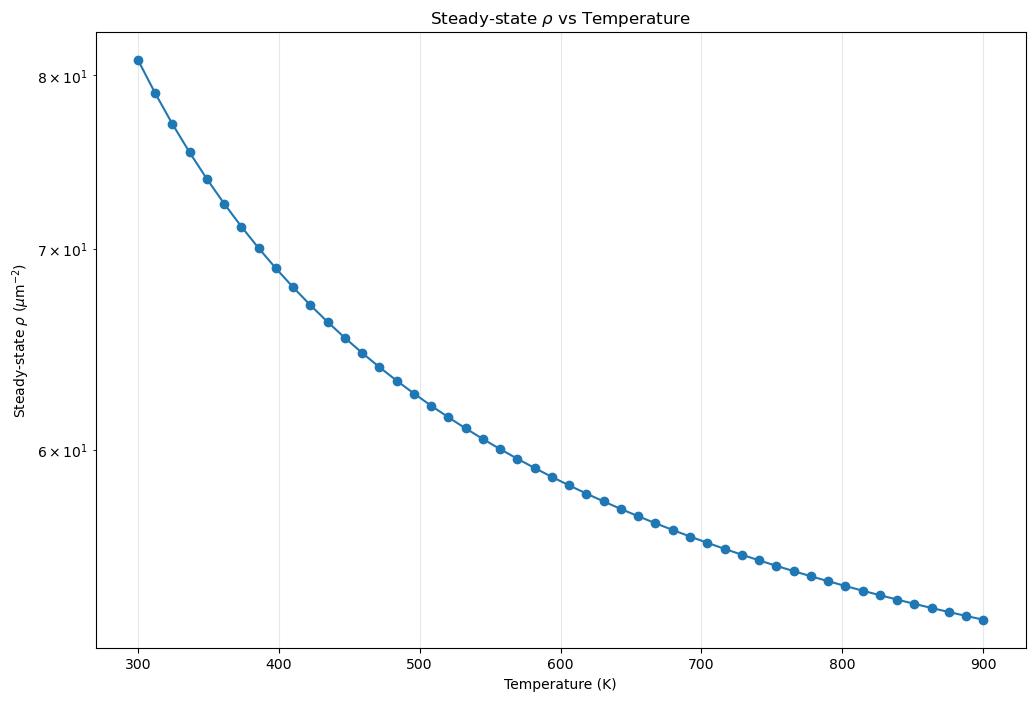

In [7]:
nmodel_inner = neml2.load_model("tungsten.i", "implicit_rate")

print(20 * "=" + " Available Buffers " + 20 * "=")
for n, b in nmodel_inner.named_buffers():
    print(f"{n}: {b}")

k1 = model.get_parameter("discrete_equations.rho_m_rate_k1").data.item()
k2_0 = model.get_parameter("discrete_equations.rho_m_rate_k2_0").data.item()
Q_d = model.get_parameter("discrete_equations.rho_m_rate_Q_d").data.item()
c_lath = 1.0
d_lath = 0.5
k_B = nmodel_inner.get_buffer("v_disl.k_B").data.item()
rho_m = model.initial_rho_m
lambda_micro = c_lath / d_lath


def rho_ss(T):
    k2 = k2_0 * np.exp(-Q_d / (k_B * T))
    sqrt_rho_ss = (k1 + np.sqrt(k1**2 + 4.0 * k1 * k2 * lambda_micro)) / (2.0 * k2)
    return sqrt_rho_ss * sqrt_rho_ss


rho_dict = {float(T): float(rho_ss(float(T))) for T in temps}

plt.figure(figsize=(12, 8))
plt.plot(temps.detach().cpu().numpy(), [rho_dict[float(T)] for T in temps], "o-")
plt.title(r"Steady-state $\rho$ vs Temperature")
plt.xlabel("Temperature (K)")
plt.ylabel(r"Steady-state $\rho$ ($\mu$m$^{-2}$)")
plt.yscale("log")
plt.grid(alpha=0.3)

In [8]:
with torch.no_grad():
    flow_stress = model(times, temperature, loading)
    print(flow_stress)
    print(flow_stress.shape)

/tmp/ipykernel_54139/4013741326.py:41: UserWarning: pyzag lowered torch._functorch.config.donated_buffer's default to False process-wide. AOTAutograd 'donated buffers' (torch>=2.12) are incompatible with pyzag's retain_graph=True adjoint over torch.compile'd models, which otherwise raises 'compiled with non-empty donated buffers'. To keep donated buffers enabled, restore torch._functorch.config._config['donated_buffer'].default = True -- compiled models differentiated through the adjoint will then error.
  solver = nonlinear.RecursiveNonlinearEquationSolver(


tensor([[[   0.0000],
         [   0.0000],
         [   0.0000],
         ...,
         [   0.0000],
         [   0.0000],
         [   0.0000]],

        [[  49.9776],
         [  49.9776],
         [  49.9776],
         ...,
         [  48.4654],
         [  48.4654],
         [  48.4654]],

        [[  99.9552],
         [  99.9552],
         [  99.9552],
         ...,
         [  96.9308],
         [  96.9308],
         [  96.9308]],

        ...,

        [[1159.6322],
         [1046.4316],
         [ 943.1697],
         ...,
         [ 280.4201],
         [ 268.6260],
         [ 266.1966]],

        [[1159.6322],
         [1046.4316],
         [ 943.1697],
         ...,
         [ 280.4201],
         [ 268.6260],
         [ 266.1966]],

        [[1159.6322],
         [1046.4316],
         [ 943.1697],
         ...,
         [ 280.4201],
         [ 268.6260],
         [ 266.1966]]], device='cuda:0')
torch.Size([200, 150, 1])


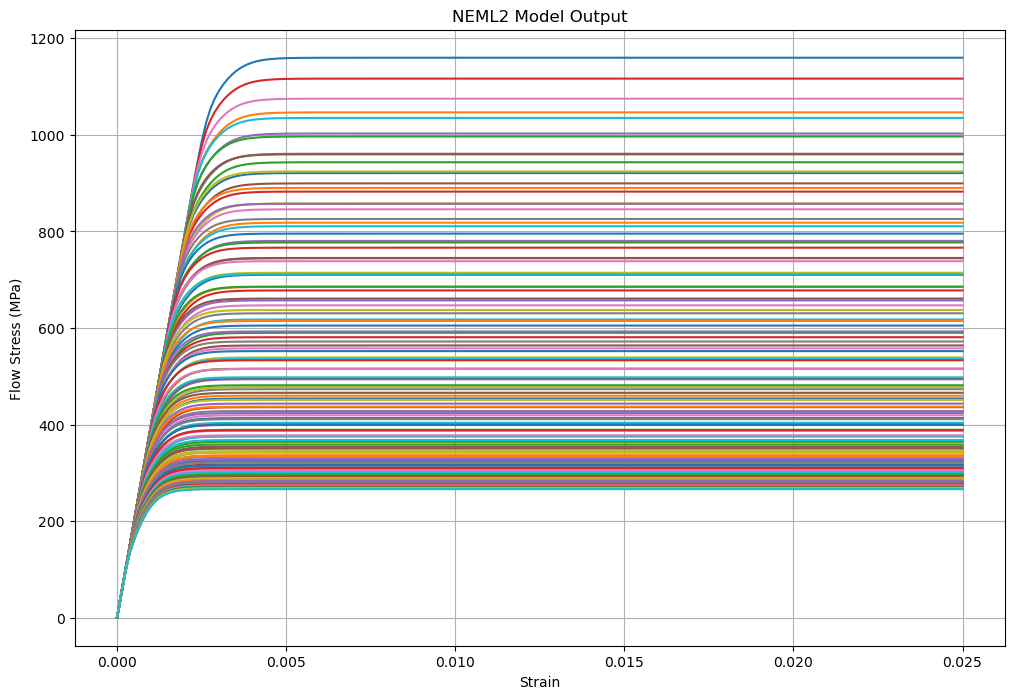

In [9]:
plt.figure(figsize=(12, 8))
for i, (T, rate) in enumerate(conditions):
    plt.plot(
        loading[:, i, 0].detach().cpu().numpy(),
        flow_stress[:, i, 0].detach().cpu().numpy(),
        label=f"T={T:.1f}K, rate={rate:.1e}",
    )
plt.title("NEML2 Model Output")
plt.xlabel("Strain")
plt.ylabel("Flow Stress (MPa)")
plt.grid()

In [10]:
# ============================================================
# Constants
# ============================================================
kB = 1.380649e-23  # J / K
eV_to_J = 1.602176634e-19  # J / eV
kB_eV = 8.617333262e-5  # eV / K

# ==========================
# Tungsten Lattice Constants
# ==========================
a = 3.16e-4  # microns
b = np.sqrt(3) / 2 * a  # microns
h = np.sqrt(2 / 3) * a  # microns
w = 25 * a  # microns

# ==========================
# Screw Velocity Parameters
# ==========================
Bk = 8.3e-11  # MPa*s
tau_p = 950  # MPa
H_0 = 4.08555042e-19  # J
p = 0.6
q = 1.4
T_0 = 3325.5  # K
m_exp = 0.33

# Keep this analytical root solve entirely in NumPy/scipy space.
rho_temperature_grid = np.array(sorted(rho_dict), dtype=float)
rho_value_grid = np.array([rho_dict[T] for T in rho_temperature_grid])


def G_of_T(T_val):
    Ea = -2.716e-2
    Eb = 0.01253e3
    Ec = 396.507e3
    nua = 3.157e-9
    nub = -8.030e-6
    nuc = 0.285
    E_T = Ea * T_val**2 + Eb * T_val + Ec
    nu_T = nua * T_val**2 + nub * T_val + nuc
    return E_T / (2 * (1 + nu_T))


def rho_of_T(T_val):
    return np.interp(
        np.asarray(T_val, dtype=float),
        rho_temperature_grid,
        rho_value_grid,
    )


def tau_a_of_T(T_val):
    alpha_a = 0.23
    lambda_micro_a = 1 / 0.5
    return alpha_a * G_of_T(T_val) * b * (np.sqrt(rho_of_T(T_val)) + lambda_micro_a)


def screw_velocity(tau_eff_val, T_val):
    K = 2 * h * b / (w * Bk)
    tau_1 = tau_eff_val - tau_a_of_T(T_val)
    mcl_tau_1 = np.maximum(tau_1, 0)
    tau_ratio = tau_1 / tau_p
    tau_ratio = np.clip(tau_ratio, 1e-30, 1.0 - 1e-6)
    dg = (1.0 - tau_ratio**p) ** q - T_val / T_0
    dg1 = np.maximum(dg, 0.0)
    exp_coeff = np.exp(-H_0 * dg1 / (2.0 * kB * T_val))
    return K * mcl_tau_1 * exp_coeff


def gamma_dot(tau_eff_val, T_val):
    return rho_of_T(T_val) * b * screw_velocity(tau_eff_val, T_val)


def solve_tau_for_g_dot(gamma_dot_target, T_val):
    gamma_dot_target = float(gamma_dot_target)
    T_val = float(T_val)
    tau_a_T = tau_a_of_T(T_val)
    tau_min = tau_a_T + 1e-6
    tau_max = tau_a_T + 0.999 * tau_p

    f_min = gamma_dot(tau_min, T_val) - gamma_dot_target
    f_max = gamma_dot(tau_max, T_val) - gamma_dot_target

    if not np.isfinite(f_min) or not np.isfinite(f_max) or f_min * f_max > 0:
        return np.nan

    return brentq(
        lambda tau: gamma_dot(tau, T_val) - gamma_dot_target,
        tau_min,
        tau_max,
        xtol=1e-12,
        rtol=1e-10,
        maxiter=500,
    )

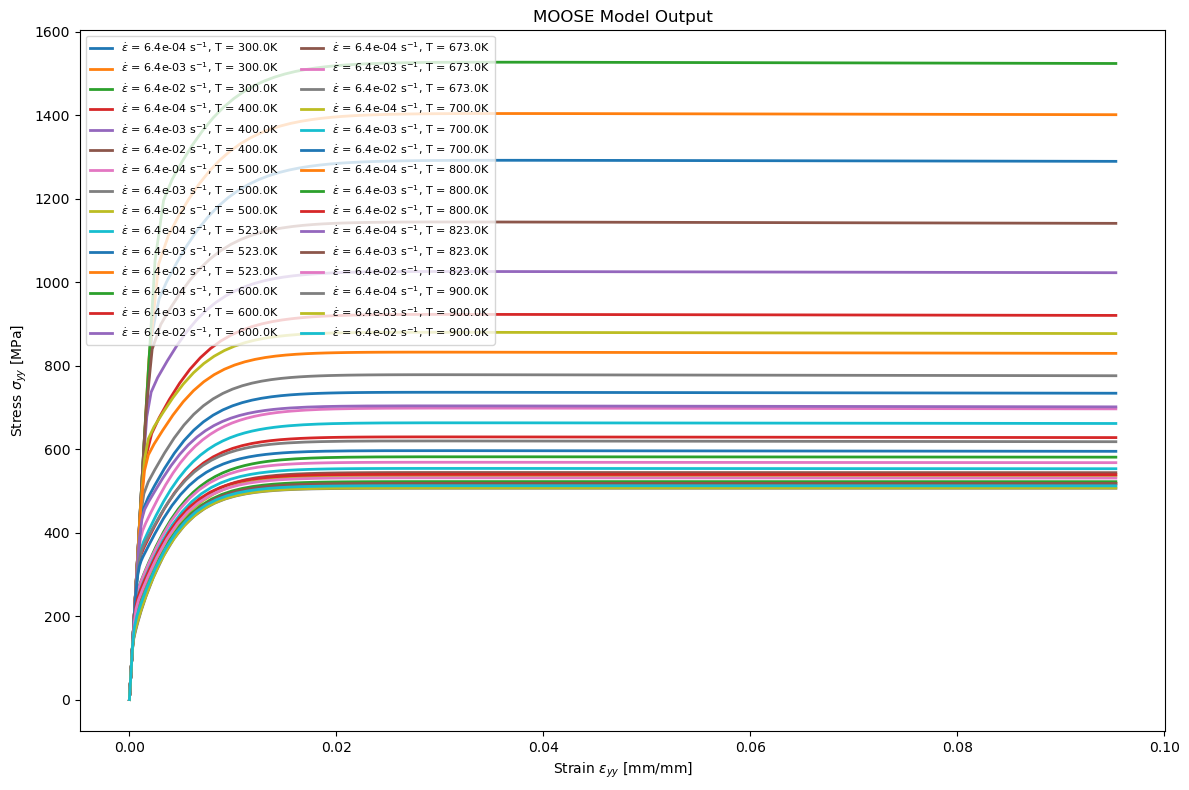

In [11]:
path = "MOOSE_validation_data"

files = [f for f in sorted(os.listdir(path)) if f.startswith("W") and f.endswith(".csv")]
pattern = re.compile(r"_T(?P<T>[\d.]+)K_rate(?P<rate>[\d.eE+-]+)\.csv$")

frames = []
for f in files:
    m = pattern.search(f)
    if m is None:
        raise ValueError(f"filename {f!r} does not match expected pattern")
    df = pd.read_csv(os.path.join(path, f))
    df["T"] = float(m.group("T"))  # from the filename -> the t=0 row keeps its group
    df["rate"] = float(m.group("rate"))
    frames.append(df)
MOOSE_data = pd.concat(frames, ignore_index=True)

by_both = dict(tuple(MOOSE_data.groupby(["T", "rate"])))
temps, rates = sorted(MOOSE_data["T"].unique()), sorted(MOOSE_data["rate"].unique())

fig, ax = plt.subplots(figsize=(12, 8))
for T in temps:
    for r in rates:
        c = by_both[(T, r)].sort_values("strain_yy")
        ax.plot(
            c["strain_yy"],
            c["stress_yy"],
            lw=2,
            label=rf"$\dot{{\epsilon}}$ = {r:.1e} s$^{{-1}}$, T = {T}K",
        )

ax.set_title("MOOSE Model Output")
ax.legend(fontsize=8, ncol=2)
ax.set_xlabel("Strain $\\epsilon_{yy}$ [mm/mm]")
ax.set_ylabel("Stress $\\sigma_{yy}$ [MPa]")
fig.tight_layout()

C101: 250C, 6.40e-04 1/s: strain range [0.0001, 0.0244]
C102: 400C, 6.40e-04 1/s: strain range [0.0005, 0.0247]
C103: 550C, 6.40e-04 1/s: strain range [0.0000, 0.0245]
C104: 250C, 6.40e-04 1/s: strain range [0.0000, 0.0248]
C105: 400C, 6.40e-04 1/s: strain range [0.0000, 0.0250]
C106: 550C, 6.40e-04 1/s: strain range [0.0000, 0.0246]
C107: 250C, 6.40e-04 1/s: strain range [0.0002, 0.0248]
C108: 400C, 6.40e-04 1/s: strain range [0.0001, 0.0247]
C109: 550C, 6.40e-04 1/s: strain range [0.0000, 0.0249]
C113: 400C, 6.40e-02 1/s: strain range [0.0000, 0.0222]
C114: 400C, 6.40e-03 1/s: strain range [0.0001, 0.0240]
C115: 250C, 6.40e-03 1/s: strain range [0.0012, 0.0240]
C116: 250C, 6.40e-03 1/s: strain range [0.0006, 0.0244]
C117: 400C, 6.40e-03 1/s: strain range [0.0005, 0.0249]
C118: 400C, 6.40e-02 1/s: strain range [0.0000, 0.0231]
C119: 550C, 6.40e-03 1/s: strain range [0.0000, 0.0242]
C120: 550C, 6.40e-03 1/s: strain range [0.0000, 0.0247]
C121: 550C, 6.40e-02 1/s: strain range [0.0006, 

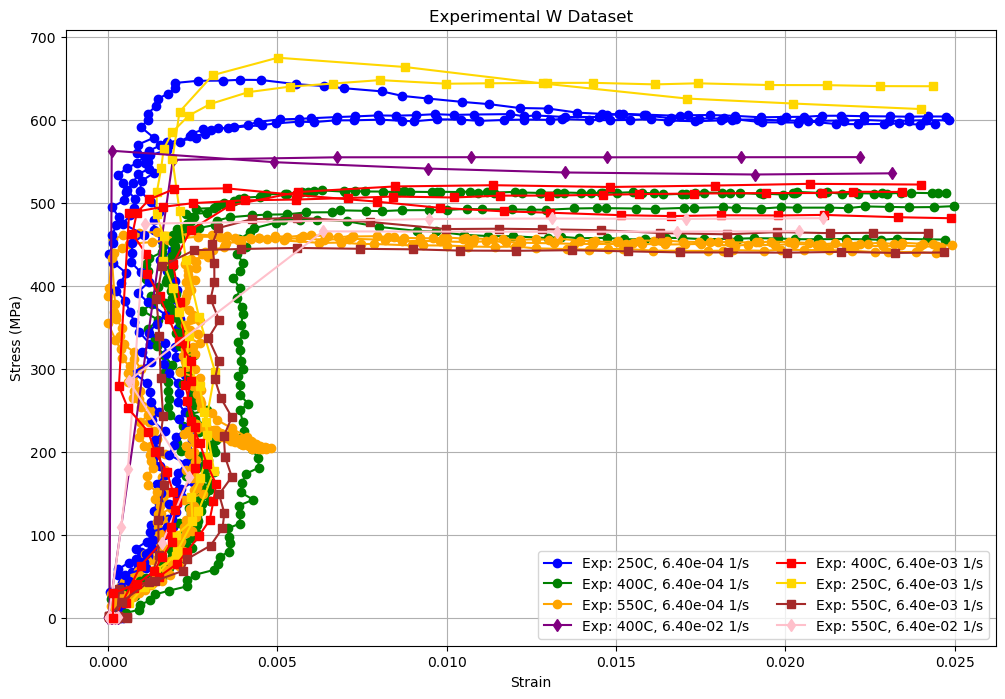

In [12]:
path = "ATW_tensile_dataset"
data_frames = {}
for filename in os.listdir(path):
    if filename.endswith(".csv"):
        file_path = os.path.join(path, filename)
        df = pd.read_csv(file_path)
        sample_name = filename.split("_")[1]
        if "250C" in filename:
            temp_str = 250
            if sample_name in ["C101", "C104", "C107"]:
                strain_rate_str = 6.4e-4
                label = f"{sample_name}: {temp_str}C, {strain_rate_str:.2e} 1/s"
            elif sample_name in ["C115", "C116"]:
                strain_rate_str = 6.4e-3
                label = f"{sample_name}: {temp_str}C, {strain_rate_str:.2e} 1/s"
            else:
                strain_rate_str = None
        elif "400C" in filename:
            temp_str = 400
            if sample_name in ["C102", "C105", "C108"]:
                strain_rate_str = 6.4e-4
                label = f"{sample_name}: {temp_str}C, {strain_rate_str:.2e} 1/s"
            elif sample_name in ["C114", "C117", "C123"]:
                strain_rate_str = 6.4e-3
                label = f"{sample_name}: {temp_str}C, {strain_rate_str:.2e} 1/s"
            elif sample_name in ["C113", "C118"]:
                strain_rate_str = 6.4e-2
                label = f"{sample_name}: {temp_str}C, {strain_rate_str:.2e} 1/s"
            else:
                strain_rate_str = None
        elif "550C" in filename:
            temp_str = 550
            if sample_name in ["C103", "C106", "C109"]:
                strain_rate_str = 6.4e-4
                label = f"{sample_name}: {temp_str}C, {strain_rate_str:.2e} 1/s"
            elif sample_name in ["C119", "C120"]:
                strain_rate_str = 6.4e-3
                label = f"{sample_name}: {temp_str}C, {strain_rate_str:.2e} 1/s"
            elif sample_name in ["C121", "C122"]:
                strain_rate_str = 6.4e-2
                label = f"{sample_name}: {temp_str}C, {strain_rate_str:.2e} 1/s"
            else:
                strain_rate_str = None
        else:
            label = None
            continue

        new_df = df.rename(columns={"x": f"{label}_strain", "y": f"{label}_stress"})
        data_frames[label] = new_df

strain_data = {}
stress_data = {}

for label, df in data_frames.items():
    strain_col = f"{label}_strain"
    stress_col = f"{label}_stress"
    if ": " in label:
        strain = torch.tensor(df[strain_col].values, device=device)
    else:
        strain = torch.tensor(df[strain_col].values * 1e-2, device=device)

    stress = torch.tensor(df[stress_col].values, device=device)

    strain = strain[:] - strain[0]
    stress = stress[:] - stress[0]

    mask = (stress > 0) & (strain <= 0.025) & (strain > 0)
    strain = strain[mask]
    stress = stress[mask]

    strain_data[label] = strain
    stress_data[label] = stress

exp_conditions = []
for label, df in data_frames.items():
    if ":" in label:
        temp_str = re.split(r"[:,]", label)[1]
        strain_rate_str = re.split(r"[:,]", label)[2]
    else:
        temp_str = label.split(",")[0]
        strain_rate_str = label.split(",")[1]

    temp = float(temp_str.replace("C", "").strip()) + 273.15  # convert to Kelvin
    strain_rate = float(strain_rate_str.replace("1/s", "").strip())
    exp_conditions.append((temp, strain_rate, label))

for i, (temp, rate, label) in enumerate(exp_conditions):
    min_strain = strain_data[label].min().item()
    max_strain = strain_data[label].max().item()

    # Experimental strain ranges
    print(f"{label}: strain range [{min_strain:.4f}, {max_strain:.4f}]")

style_map = {
    (250, 6.4e-4): ("blue", "o"),
    (250, 6.4e-3): ("gold", "s"),
    (400, 6.4e-4): ("green", "o"),
    (400, 6.4e-3): ("red", "s"),
    (400, 6.4e-2): ("purple", "d"),
    (480, 1.0e-3): ("cyan", "o"),
    (550, 6.4e-4): ("orange", "o"),
    (550, 6.4e-3): ("brown", "s"),
    (550, 6.4e-2): ("pink", "d"),
}

# Plot initial dataset
plt.figure(figsize=(12, 8))
plotted_conditions = set()
for label in strain_data:
    T_exp = next(T for T, r, l in exp_conditions if l == label)
    rate_exp = next(r for T, r, l in exp_conditions if l == label)
    temp_C = round(T_exp - 273.15)
    color, marker = style_map.get((temp_C, rate_exp), ("k", "o"))

    # Only add one legend entry per condition (not one per replicate)
    cond_key = (temp_C, rate_exp)
    legend_label = (
        f"Exp: {temp_C}C, {rate_exp:.2e} 1/s"
        if cond_key not in plotted_conditions
        else "_nolegend_"
    )
    plotted_conditions.add(cond_key)
    plt.plot(
        strain_data[label].cpu().numpy(),
        stress_data[label].cpu().numpy(),
        color=color,
        marker=marker,
        label=legend_label,
    )
plt.xlabel("Strain")
plt.ylabel("Stress (MPa)")
plt.title("Experimental W Dataset")
plt.grid()
plt.legend(loc="lower right", ncol=2)
plt.show()

NEML2 vs analytical tau_eff RMSE: 2.16624 MPa


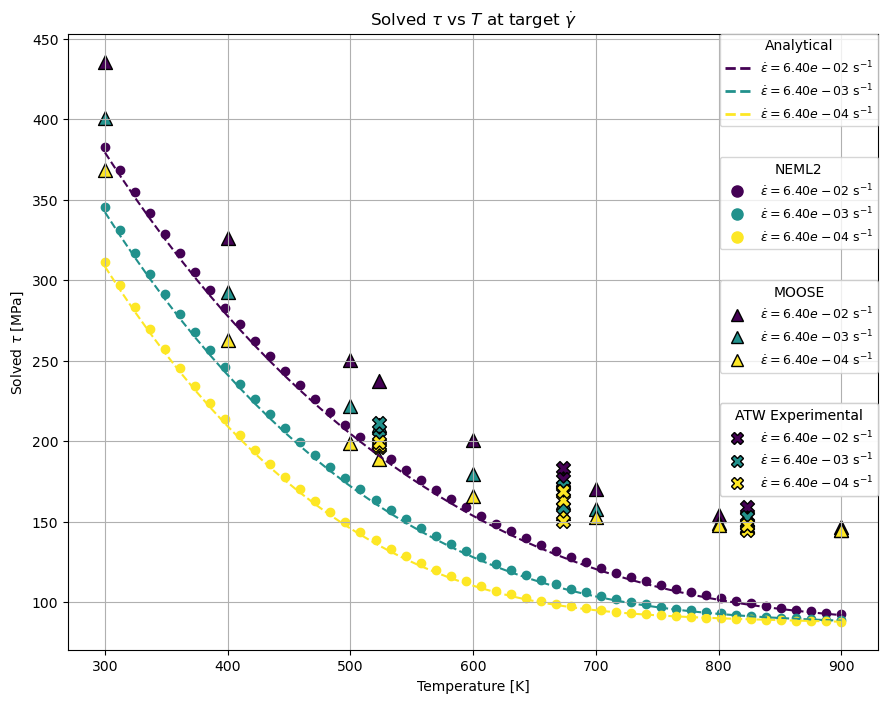

In [13]:
# ============================================================
# Analytical Calculation vs. NEML2 Output
# ============================================================
erate = np.array([6.4e-2, 6.4e-3, 6.4e-4])
T_sweep = np.linspace(300.0, 900.0, 50)

# NEML2 reports tau_eff = m * sigma, so compare both models in tau_eff.
flow_stress_final = flow_stress[-10:, ...].mean(dim=0)
batch_temps = conditions[:, 0]
batch_rates = conditions[:, 1]
m = nmodel_inner.get_buffer("v_disl.m").data.item()
tau_eff = m * flow_stress_final

batch_temperature_np = batch_temps.detach().cpu().numpy().reshape(-1)
batch_rate_np = batch_rates.detach().cpu().numpy().reshape(-1)
neml2_tau_eff_np = tau_eff.detach().cpu().numpy().reshape(-1)

# =======================================================
# Plotting for Analytical, NEML2, MOOSE, and ATW datasets
# =======================================================

fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(erate)))

# Analytical plot
for i, target_rate in enumerate(erate):
    target_gdot = target_rate / m
    tau_solutions = np.array([solve_tau_for_g_dot(target_gdot, T_val) for T_val in T_sweep])
    ax.plot(
        T_sweep,
        tau_solutions,
        "--",
        color=colors[i],
        label=rf"Analytical, $\dot{{\epsilon}}={target_rate:.2e}$ $s^{{-1}}$",
    )

# NEML2 Plot
for i, target_rate in enumerate(erate):
    rate_mask = np.isclose(batch_rate_np, target_rate, rtol=1e-6, atol=1e-12)
    ax.scatter(
        batch_temperature_np[rate_mask],
        neml2_tau_eff_np[rate_mask],
        color=colors[i],
        marker="o",
        label=rf"NEML2, $\dot{{\epsilon}}={target_rate:.2e}$ $s^{{-1}}$",
    )

# MOOSE model output
MOOSE_tau_eff_list = []
MOOSE_temps_list = []
MOOSE_rates_list = []
for T in temps:
    for r in rates:
        c = by_both[(T, r)].sort_values("strain_yy")
        MOOSE_tau_eff = c["tau_eff_avg"].iloc[-1]
        MOOSE_tau_eff_list.append(MOOSE_tau_eff)
        MOOSE_temps_list.append(T)
        MOOSE_rates_list.append(r)

MOOSE_temps_np = np.array(MOOSE_temps_list)
MOOSE_rates_np = np.array(MOOSE_rates_list)
MOOSE_tau_eff_np = np.array(MOOSE_tau_eff_list)

# MOOSE plot
for i, target_rate in enumerate(erate):
    rate_mask = np.isclose(MOOSE_rates_np, target_rate, rtol=1e-6, atol=1e-12)
    ax.scatter(
        MOOSE_temps_np[rate_mask],
        MOOSE_tau_eff_np[rate_mask],
        color=colors[i],
        marker="^",
        edgecolors="k",
        s=100,
        label=rf"MOOSE, $\dot{{\epsilon}}={target_rate:.2e}$ $s^{{-1}}$",
    )

# ATW dataset
ATW_tau_eff_list = []
ATW_temps_list = []
ATW_rates_list = []
for i, label in enumerate(strain_data):
    ATW_flow_stress = stress_data[label][-1]
    ATW_tau_eff = ATW_flow_stress.cpu() * m_exp
    ATW_rates = next(r for T, r, l in exp_conditions if l == label)
    ATW_temps = next(T for T, r, l in exp_conditions if l == label)
    ATW_tau_eff_list.append(ATW_tau_eff)
    ATW_temps_list.append(ATW_temps)
    ATW_rates_list.append(ATW_rates)

ATW_tau_eff_np = np.array(ATW_tau_eff_list)
ATW_temps_np = np.array(ATW_temps_list)
ATW_rates_np = np.array(ATW_rates_list)

# ATW plot
for i, target_rate in enumerate(erate):
    rate_mask = np.isclose(ATW_rates_np, target_rate, rtol=1e-6, atol=1e-12)
    ax.scatter(
        ATW_temps_np[rate_mask],
        ATW_tau_eff_np[rate_mask],
        color=colors[i],
        marker="X",
        edgecolors="k",
        s=100,
        label=rf"ATW, $\dot{{\epsilon}}={target_rate:.2e}$ $s^{{-1}}$",
    )

# =======================================================
# Legends
# =======================================================
analytical_handles = [
    Line2D(
        [0],
        [0],
        color=colors[i],
        lw=2,
        linestyle="--",
        label=rf"$\dot{{\epsilon}}={target_rate:.2e}$ s$^{{-1}}$",
    )
    for i, target_rate in enumerate(erate)
]

neml2_handles = [
    Line2D(
        [0],
        [0],
        color=colors[i],
        marker="o",
        linestyle="None",
        markersize=8,
        label=rf"$\dot{{\epsilon}}={target_rate:.2e}$ s$^{{-1}}$",
    )
    for i, target_rate in enumerate(erate)
]

moose_handles = [
    Line2D(
        [0],
        [0],
        color=colors[i],
        marker="^",
        linestyle="None",
        markeredgecolor="k",
        markersize=8,
        label=rf"$\dot{{\epsilon}}={target_rate:.2e}$ s$^{{-1}}$",
    )
    for i, target_rate in enumerate(erate)
]

atw_handles = [
    Line2D(
        [0],
        [0],
        color=colors[i],
        marker="X",
        linestyle="None",
        markeredgecolor="k",
        markersize=8,
        label=rf"$\dot{{\epsilon}}={target_rate:.2e}$ s$^{{-1}}$",
    )
    for i, target_rate in enumerate(erate)
]

legend_analytical = ax.legend(
    handles=analytical_handles,
    loc="upper right",
    bbox_to_anchor=(1.0, 1.0),
    fontsize=9,
    title="Analytical",
    borderaxespad=0.0,
)
ax.add_artist(legend_analytical)

legend_neml2 = ax.legend(
    handles=neml2_handles,
    loc="upper right",
    bbox_to_anchor=(1.0, 0.8),
    fontsize=9,
    title="NEML2",
    borderaxespad=0.0,
)
ax.add_artist(legend_neml2)

legend_moose = ax.legend(
    handles=moose_handles,
    loc="upper right",
    bbox_to_anchor=(1.0, 0.6),
    fontsize=9,
    title="MOOSE",
    borderaxespad=0.0,
)
ax.add_artist(legend_moose)

legend_atw = ax.legend(
    handles=atw_handles,
    loc="upper right",
    bbox_to_anchor=(1.0, 0.4),
    fontsize=9,
    title="ATW Experimental",
    borderaxespad=0.0,
)
ax.add_artist(legend_atw)

fig.subplots_adjust(right=0.8)

# Evaluate the analytical solution at the exact NEML2 temperatures for a numerical comparison.
analytical_tau_at_neml2 = np.array(
    [
        solve_tau_for_g_dot(rate / m, temperature_value)
        for rate, temperature_value in zip(batch_rate_np, batch_temperature_np)
    ]
)
valid = np.isfinite(analytical_tau_at_neml2) & np.isfinite(neml2_tau_eff_np)
if np.any(valid):
    rmse = np.sqrt(np.mean((analytical_tau_at_neml2[valid] - neml2_tau_eff_np[valid]) ** 2))
    print(f"NEML2 vs analytical tau_eff RMSE: {rmse:.6g} MPa")

ax.set_xlabel("Temperature [K]")
ax.set_ylabel(r"Solved $\tau$ [MPa]")
ax.set_title(r"Solved $\tau$ vs $T$ at target $\dot{\gamma}$")
ax.grid(True)
plt.show()

In [14]:
batch_conditions = [
    (523.15, 6.4e-4),
    (523.15, 6.4e-3),
    (673.15, 6.4e-4),
    (673.15, 6.4e-3),
    (673.15, 6.4e-2),
    (823.15, 6.4e-4),
    (823.15, 6.4e-3),
    (823.15, 6.4e-2),
]

temperature = torch.tensor([c[0] for c in batch_conditions], device=device)
rates = torch.tensor([c[1] for c in batch_conditions], device=device)

nbatch = len(batch_conditions)
ntime = 200

time = torch.zeros((ntime, nbatch), device=device)
temperature = torch.zeros((ntime, nbatch), device=device)
loading = torch.zeros((ntime, nbatch, 6), device=device)

for i, (T, rate) in enumerate(batch_conditions):
    max_strain = 0.025
    strain_values = torch.linspace(0.0, max_strain, ntime, device=device)
    time_values = torch.linspace(0.0, max_strain / rate, ntime, device=device)
    loading[:, i, 0] = strain_values
    time[:, i] = time_values

    # Set temperature (in Kelvin)
    temperature[:, i] = T

print(
    f"\n--- Full Input Tensors ---\ntime: {time.shape}\ntemperature: {temperature.shape}\nloading: {loading.shape}"
)


--- Full Input Tensors ---
time: torch.Size([200, 8])
temperature: torch.Size([200, 8])
loading: torch.Size([200, 8, 6])


    Batch 0 250C 6.40e-04 1/s -> 3 curves: ['C101: 250C, 6.40e-04 1/s', 'C104: 250C, 6.40e-04 1/s', 'C107: 250C, 6.40e-04 1/s']
    Batch 1 250C 6.40e-03 1/s -> 2 curves: ['C115: 250C, 6.40e-03 1/s', 'C116: 250C, 6.40e-03 1/s']
    Batch 2 400C 6.40e-04 1/s -> 3 curves: ['C102: 400C, 6.40e-04 1/s', 'C105: 400C, 6.40e-04 1/s', 'C108: 400C, 6.40e-04 1/s']
    Batch 3 400C 6.40e-03 1/s -> 3 curves: ['C114: 400C, 6.40e-03 1/s', 'C117: 400C, 6.40e-03 1/s', 'C123: 400C, 6.40e-03 1/s']
    Batch 4 400C 6.40e-02 1/s -> 2 curves: ['C113: 400C, 6.40e-02 1/s', 'C118: 400C, 6.40e-02 1/s']
    Batch 5 550C 6.40e-04 1/s -> 3 curves: ['C103: 550C, 6.40e-04 1/s', 'C106: 550C, 6.40e-04 1/s', 'C109: 550C, 6.40e-04 1/s']
    Batch 6 550C 6.40e-03 1/s -> 2 curves: ['C119: 550C, 6.40e-03 1/s', 'C120: 550C, 6.40e-03 1/s']
    Batch 7 550C 6.40e-02 1/s -> 2 curves: ['C121: 550C, 6.40e-02 1/s', 'C122: 550C, 6.40e-02 1/s']
Interpolated data shape:
strain: torch.Size([200, 8, 6])
stress: torch.Size([200, 8, 6])

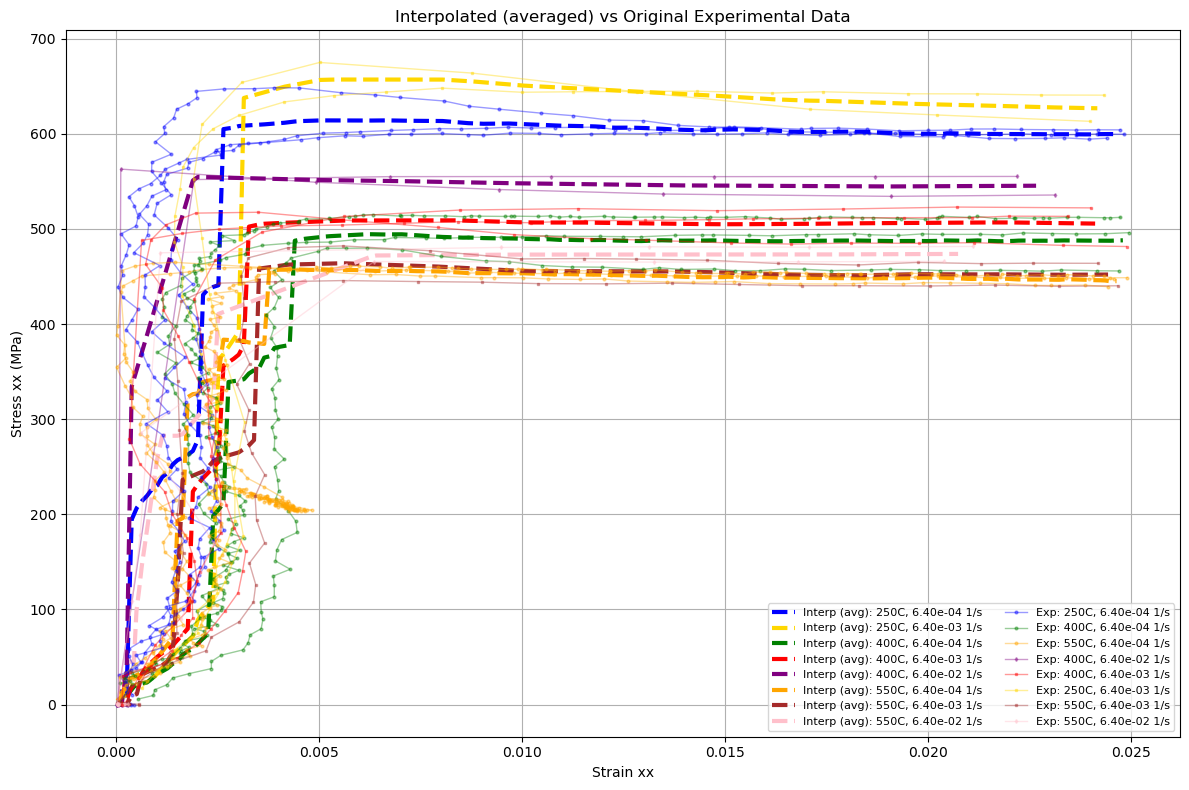

In [15]:
exp_stress_data = torch.zeros_like(loading, device=device)
exp_strain_data = torch.zeros_like(loading, device=device)

batch_to_labels = defaultdict(list)
for i, (bT, b_rate) in enumerate(batch_conditions):
    for j, (T, rate, label) in enumerate(exp_conditions):
        if abs(T - bT) == 0.0 and abs(rate - b_rate) == 0.0:
            batch_to_labels[i].append(label)

for i, (T, rate) in enumerate(batch_conditions):
    labels = batch_to_labels.get(i, [])
    print(f"    Batch {i:d} {T - 273.15:.0f}C {rate:.2e} 1/s -> {len(labels)} curves: {labels}")

    # Model loading is in strain fraction; experimental data is in percent.
    target_strain = loading[:, i, 0].cpu().numpy()

    replicate_strains = []
    replicate_stresses = []

    for label in labels:
        src_strain = strain_data[label].cpu().numpy()
        src_stress = stress_data[label].cpu().numpy()

        tgt_clipped = np.clip(target_strain, src_strain.min(), src_strain.max())
        interp_stress = np.interp(tgt_clipped, src_strain, src_stress)

        replicate_strains.append(tgt_clipped)
        replicate_stresses.append(interp_stress)

    mean_strain = np.mean(replicate_strains, axis=0)
    mean_stress = np.mean(replicate_stresses, axis=0)

    exp_strain_data[:, i, 0] = torch.tensor(mean_strain, device=device)
    exp_stress_data[:, i, 0] = torch.tensor(mean_stress, device=device)

print(f"Interpolated data shape:")
print(f"strain: {exp_strain_data.shape}")
print(f"stress: {exp_stress_data.shape}")

print("Saturated Stress values")
for i, (T, rate) in enumerate(batch_conditions):
    print(f"  Batch {i} {T - 273.15}C {rate:.2e} 1/s -> {exp_stress_data[-1, i, 0].item():.2f} MPa")

# Color/marker scheme keyed by (temp_C, rate)
style_map = {
    (250, 6.4e-4): ("blue", "o"),
    (250, 6.4e-3): ("gold", "s"),
    (400, 6.4e-4): ("green", "o"),
    (400, 6.4e-3): ("red", "s"),
    (400, 6.4e-2): ("purple", "d"),
    (550, 6.4e-4): ("orange", "o"),
    (550, 6.4e-3): ("brown", "s"),
    (550, 6.4e-2): ("pink", "d"),
}

fig, ax = plt.subplots(figsize=(12, 8))

# ── Interpolated (averaged) curves ──────────────────────────────────────────
for i, (T, rate) in enumerate(batch_conditions):
    temp_C = round(T - 273.15)
    color, _ = style_map.get((temp_C, rate), (f"C{i}", "o"))
    batch_label = f"{temp_C}C, {rate:.2e} 1/s"
    ax.plot(
        exp_strain_data[:, i, 0].cpu().numpy(),
        exp_stress_data[:, i, 0].cpu().numpy(),
        "--",
        color=color,
        lw=3,
        label=f"Interp (avg): {batch_label}",
    )

# ── Original replicate curves ────────────────────────────────────────────────
plotted_conditions = set()
for label in strain_data:
    T_exp = next(T for T, r, l in exp_conditions if l == label)
    rate_exp = next(r for T, r, l in exp_conditions if l == label)
    temp_C = round(T_exp - 273.15)
    color, marker = style_map.get((temp_C, rate_exp), ("k", "o"))

    # Only add one legend entry per condition (not one per replicate)
    cond_key = (temp_C, rate_exp)
    legend_label = (
        f"Exp: {temp_C}C, {rate_exp:.2e} 1/s"
        if cond_key not in plotted_conditions
        else "_nolegend_"
    )
    plotted_conditions.add(cond_key)

    ax.plot(
        strain_data[label].cpu().numpy(),
        stress_data[label].cpu().numpy(),
        color=color,
        alpha=0.4,
        lw=1,
        marker=marker,
        markersize=2,
        label=legend_label,
    )

ax.set_xlabel("Strain xx")
ax.set_ylabel("Stress xx (MPa)")
ax.set_title("Interpolated (averaged) vs Original Experimental Data")
ax.grid(True)
ax.legend(loc="lower right", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

In [16]:
with torch.no_grad():
    stress = model(time, temperature, loading)
print(stress)
print(stress.shape)

tensor([[[  0.0000],
         [  0.0000],
         [  0.0000],
         ...,
         [  0.0000],
         [  0.0000],
         [  0.0000]],

        [[ 49.7021],
         [ 49.7021],
         [ 49.3259],
         ...,
         [ 48.7962],
         [ 48.7962],
         [ 48.7962]],

        [[ 99.4042],
         [ 99.4042],
         [ 98.6519],
         ...,
         [ 97.5925],
         [ 97.5925],
         [ 97.5925]],

        ...,

        [[415.6137],
         [491.5278],
         [297.7256],
         ...,
         [271.1643],
         [277.9713],
         [301.8839]],

        [[415.6137],
         [491.5278],
         [297.7256],
         ...,
         [271.1643],
         [277.9713],
         [301.8839]],

        [[415.6137],
         [491.5278],
         [297.7256],
         ...,
         [271.1643],
         [277.9713],
         [301.8839]]], device='cuda:0')
torch.Size([200, 8, 1])


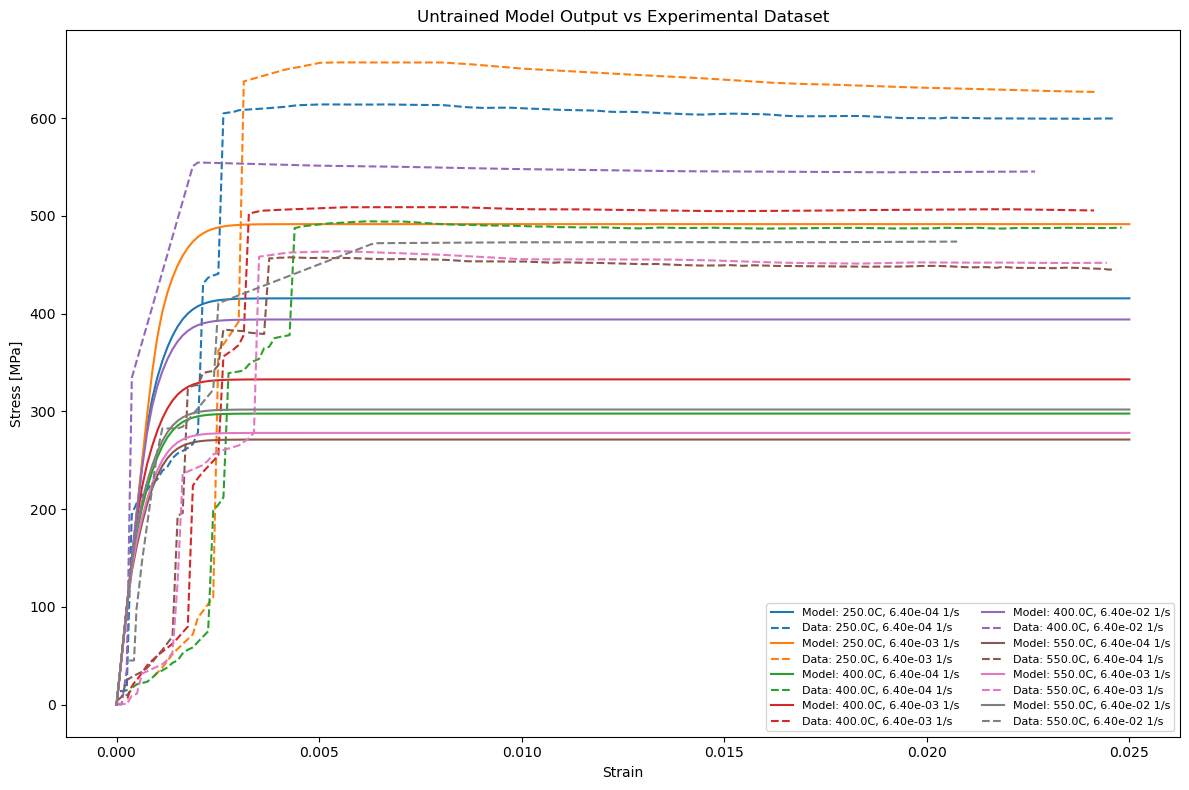

In [17]:
plt.figure(figsize=(12, 8))
for i, (T, rate) in enumerate(batch_conditions):
    batch_label = f"{T - 273.15}C, {rate:.2e} 1/s"
    plt.plot(
        loading[:, i, 0].cpu().numpy(),
        stress[:, i, 0].cpu().numpy(),
        color=f"C{i}",
        label=f"Model: {batch_label}",
    )
    plt.plot(
        exp_strain_data[:, i, 0].cpu().numpy(),
        exp_stress_data[:, i, 0].cpu().numpy(),
        "--",
        color=f"C{i}",
        label=f"Data: {batch_label}",
    )
plt.legend(loc="lower right", fontsize=8, ncol=2)
plt.xlabel("Strain")
plt.ylabel("Stress [MPa]")
plt.title("Untrained Model Output vs Experimental Dataset")
plt.tight_layout()
plt.show()

In [18]:
initial_params = {}
print("--- Before Reparameterization ---")
with torch.no_grad():
    for n, p in model.named_parameters():
        if p.dim() == 0:
            p.data = p.data.reshape(1)
        initial_params[n] = p.data.detach().clone()
        print(f"{n}: {p.data}, {p.shape}\n")

--- Before Reparameterization ---
discrete_equations.v_disl_B_k: tensor([8.3000e-11], device='cuda:0'), torch.Size([1])

discrete_equations.v_disl_T_0: tensor([3325.5000], device='cuda:0'), torch.Size([1])

discrete_equations.v_disl_p: tensor([0.6000], device='cuda:0'), torch.Size([1])

discrete_equations.v_disl_q: tensor([1.4000], device='cuda:0'), torch.Size([1])

discrete_equations.v_disl_H_0: tensor([2.5500], device='cuda:0'), torch.Size([1])

discrete_equations.rho_m_rate_k1: tensor([30000.], device='cuda:0'), torch.Size([1])

discrete_equations.rho_m_rate_k2_0: tensor([6000.], device='cuda:0'), torch.Size([1])

discrete_equations.rho_m_rate_Q_d: tensor([0.0100], device='cuda:0'), torch.Size([1])



In [19]:
Bk_scaler = reparametrization.RangeRescale(
    torch.tensor([1.0e-20], device=device), torch.tensor([5.0e-3], device=device)
)  # MPa*s
T_0_scaler = reparametrization.RangeRescale(
    torch.tensor([2000.0], device=device), torch.tensor([5000.0], device=device)
)  # K
p_scaler = reparametrization.RangeRescale(
    torch.tensor([0.01], device=device), torch.tensor([10.0], device=device)
)
q_scaler = reparametrization.RangeRescale(
    torch.tensor([0.01], device=device), torch.tensor([10.0], device=device)
)
H0_scaler = reparametrization.RangeRescale(
    torch.tensor([0.1], device=device), torch.tensor([10.0], device=device)
)  # eV
k1_scaler = reparametrization.RangeRescale(
    torch.tensor([1000.0], device=device), torch.tensor([1.0e7], device=device)
)  # um^-1
k2_0_scaler = reparametrization.RangeRescale(
    torch.tensor([0.01], device=device), torch.tensor([1.0e-4], device=device)
)
Q_d_scaler = reparametrization.RangeRescale(
    torch.tensor([0.001], device=device), torch.tensor([0.1], device=device)
)  # eV

model_reparameterizer = reparametrization.Reparameterizer(
    {
        "discrete_equations.v_disl_B_k": Bk_scaler,
        "discrete_equations.v_disl_T_0": T_0_scaler,
        "discrete_equations.v_disl_p": p_scaler,
        "discrete_equations.v_disl_q": q_scaler,
        "discrete_equations.v_disl_H_0": H0_scaler,
        "discrete_equations.rho_m_rate_k1": k1_scaler,
        "discrete_equations.rho_m_rate_k2_0": k2_0_scaler,
        "discrete_equations.rho_m_rate_Q_d": Q_d_scaler,
    },
    error_not_provided=True,
)
model_reparameterizer(model)
print(f"--- After Reparameterization ---")
initial_params_reparam = {}
for n, p in model.named_parameters():
    initial_params_reparam[n] = p.data.detach().clone()
    print(f"{n}: {p.data}, requires_grad={p.requires_grad}")

--- After Reparameterization ---
discrete_equations.parametrizations.v_disl_B_k.original: tensor([1.6600e-08], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.v_disl_T_0.original: tensor([0.4418], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.v_disl_p.original: tensor([0.0591], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.v_disl_q.original: tensor([0.1391], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.v_disl_H_0.original: tensor([0.2475], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.rho_m_rate_k1.original: tensor([0.0029], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.rho_m_rate_k2_0.original: tensor([0.], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.rho_m_rate_Q_d.original: tensor([0.0909], device='cuda:0'), requires_grad=True


In [20]:
base_lr = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=base_lr)
loss_fn = torch.nn.MSELoss(reduction="mean")
optimizer.zero_grad()

res = model(time, temperature, loading)
peak_stress = exp_stress_data[-1, :, 0:1].detach()
res_norm = res / (peak_stress + 1e-8)
exp_norm = exp_stress_data[..., 0:1] / (peak_stress + 1e-8)

loss = loss_fn(res_norm, exp_norm)
loss.backward()

for n, param in model.named_parameters():
    if param.grad is None:
        print(f"{n}: grad is None")
        continue
    grad_norm = param.grad.norm().item()
    if param.grad == 0.0:
        print(f"{n}: grad_norm = 0.0 (no sensitivity on this batch)")
        continue
    target_grad = 1.0
    if param.grad is not None:
        lr_param = base_lr * (target_grad / grad_norm)
        print(f"{n}: grad_norm = {param.grad.norm().item():.4e} | tuned LR: {lr_param:.2e}")

discrete_equations.parametrizations.v_disl_B_k.original: grad_norm = 1.1513e+06 | tuned LR: 8.69e-10
discrete_equations.parametrizations.v_disl_T_0.original: grad_norm = 7.6711e-02 | tuned LR: 1.30e-02
discrete_equations.parametrizations.v_disl_p.original: grad_norm = 1.6173e+00 | tuned LR: 6.18e-04
discrete_equations.parametrizations.v_disl_q.original: grad_norm = 2.2821e-01 | tuned LR: 4.38e-03
discrete_equations.parametrizations.v_disl_H_0.original: grad_norm = 1.5040e+00 | tuned LR: 6.65e-04
discrete_equations.parametrizations.rho_m_rate_k1.original: grad_norm = 1.0063e+04 | tuned LR: 9.94e-08
discrete_equations.parametrizations.rho_m_rate_k2_0.original: grad_norm = 6.4240e-04 | tuned LR: 1.56e+00
discrete_equations.parametrizations.rho_m_rate_Q_d.original: grad_norm = 1.0628e-03 | tuned LR: 9.41e-01


In [21]:
niter = 2000

param_lr_map = {
    "discrete_equations.parametrizations.v_disl_B_k.original": 8.69e-10,
    "discrete_equations.parametrizations.v_disl_T_0.original": 1.30e-2,
    "discrete_equations.parametrizations.v_disl_p.original": 6.18e-4,
    "discrete_equations.parametrizations.v_disl_q.original": 4.38e-3,
    "discrete_equations.parametrizations.v_disl_H_0.original": 6.65e-4,
    "discrete_equations.parametrizations.rho_m_rate_k1.original": 9.94e-8,
    "discrete_equations.parametrizations.rho_m_rate_k2_0.original": 1.56e0,
    "discrete_equations.parametrizations.rho_m_rate_Q_d.original": 9.41e-1,
}

param_groups = []
for name, params in model.named_parameters():
    lr = param_lr_map.get(name, 1e-3)
    param_groups.append({"params": [params], "lr": lr})

optimizer = torch.optim.Adam(param_groups)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer,
    mode="min",
    factor=0.5,
    patience=150,
    threshold=1e-4,
)

titer = tqdm.tqdm(
    range(niter),
    bar_format="{desc}: {percentage:3.0f}%|{bar}|{n_fmt}/{total_fmt}{postfix}",
)
titer.set_description("Loss:")
loss_history = []

for i in titer:
    optimizer.zero_grad()
    try:
        res = model(time, temperature, loading)
        res_norm = res / (peak_stress + 1e-8)
        exp_norm = exp_stress_data[..., 0:1] / (peak_stress + 1e-8)
        loss = loss_fn(res_norm, exp_norm)

        # --- Bug fix: guard BEFORE backward ---
        if not torch.isfinite(loss) or loss.item() > 1e6:
            titer.set_description(f"Loss: [SKIP bad solve @ iter {i}]")
            continue  # skip backward + step entirely

        loss.backward()
        optimizer.step()

        loss_history.append(loss.detach().clone().cpu())
        titer.set_description("Loss: %3.2e" % loss_history[-1])

    except RuntimeError:
        titer.set_description(f"Loss: [SOLVER FAIL @ iter {i}]")
        continue

# --- Plots ---
plt.figure()
plt.loglog(loss_history, label="Training")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.legend()
plt.title("Loss history")

plt.figure()
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Loss history (linear scale)")
plt.show()

Loss: [SOLVER FAIL @ iter 262]: :  13%|█▎        |263/2000


KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(12, 8))
for i, (T, rate) in enumerate(batch_conditions):
    batch_label = f"{T - 273.15}C, {rate:.2e} 1/s"
    plt.plot(
        loading[:, i, 0].cpu().numpy(),
        res[:, i, 0].cpu().detach().numpy(),
        color=f"C{i}",
        label=f"Model: {batch_label}",
    )
    plt.plot(
        exp_strain_data[:, i, 0].cpu().numpy(),
        exp_stress_data[:, i, 0].cpu().numpy(),
        "--",
        color=f"C{i}",
        label=f"Data: {batch_label}",
    )
plt.legend(loc="lower right", fontsize=8, ncol=2)
plt.xlabel("Strain [%]")
plt.ylabel("Stress [MPa]")
plt.title("Trained Model Output vs Experimental Dataset")
plt.tight_layout()
plt.show()

In [ ]:
print("Parameter Optimization Results:")
print("-" * 80)
for n, p in model.named_parameters():
    nice_name = n.split(".")[-1]
    print(nice_name)
    ref_name = "discrete_equations." + nice_name
    scaler = model_reparameterizer.map_dict[ref_name]
    final = scaler(p.data).cpu()
    print(f"\nParameter: {n}")
    print(f"  Initial:  {initial_params[nice_name].cpu()}")
    print(f"  Final:    {final}")
print("-" * 80)

In [ ]:
for i, (T, rate) in enumerate(batch_conditions):
    exp_fs = exp_stress_data[-1, i, 0].item()
    model_fs = res[-1, i, 0].item()
    diff = abs(exp_fs - model_fs)
    print(
        f"B{i}: ({T - 273.15}C, {rate:.2e} 1/s): Exp flow stress: {exp_stress_data[-1, i, 0].item():.2f} MPa, Model flow stress: {res[-1, i, 0].item():.2f} MPa | Diff: {diff:.2f} MPa"
    )